In [32]:
nth_prime(400)

2741

In [ ]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

D = delta_qexp(4000) 
h_list=[1]+[D[nth_prime(k)] for k in range(1,501)]
j_list=j_sequence_from_h(h_list)
c=1
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
log_mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))
        log_mins_list.append((n,log(minn)))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()  

with open('/Users/barrybrent/data2/run16jun26no1.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 
with open('/Users/barrybrent/data2/run16jun26no2.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run16jun26no3.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run16jun26no4.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
    # stored on Zenodo at https://zenodo.org/records/20726940
with open('/Users/barrybrent/data2/run16jun26no5.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run16jun26no6.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped
with open('/Users/barrybrent/data2/run16jun26no7.txt', 'wb') as wfile:
    pickle.dump(log_mins_list, wfile)



In [24]:
binomial(4,2)

6

In [28]:
RR(10**1000)

1.00000000000000e1000

In [47]:
import pickle
with open('/Users/barrybrent/data2/run16jun26no3.txt', 'rb') as rfile:
    deformed_h_list = pickle.load(rfile)
r=-1
for x in deformed_h_list[:501]:
    r+=1
    if r>0:
        print((r,CC(log(log(log(log(abs(x))))))))

(1, +infinity)
(2, -2.17847475741998 + 3.14159265358979*I)
(3, -1.41475556141513)
(4, -0.275894463806877)
(5, -0.109382832319002)
(6, -0.0194930870125814)
(7, 0.00771626514654832)
(8, 0.0933891069763449)
(9, 0.140378937311432)
(10, 0.170601977866896)
(11, 0.185625178064990)
(12, 0.218060578355974)
(13, 0.242302007760576)
(14, 0.259313558247951)
(15, 0.269298188413439)
(16, 0.286697057695011)
(17, 0.302608752231528)
(18, 0.314095704622366)
(19, 0.321569508497507)
(20, 0.332301014324832)
(21, 0.344067714946274)
(22, 0.352629922206524)
(23, 0.358578816567750)
(24, 0.365671081960494)
(25, 0.375061190229189)
(26, 0.381845221025262)
(27, 0.386773802730759)
(28, 0.391568471012582)
(29, 0.399501170500562)
(30, 0.405105170332983)
(31, 0.409305299965871)
(32, 0.412439768535238)
(33, 0.419499209375416)
(34, 0.424271484552762)
(35, 0.427927181539406)
(36, 0.429595995356091)
(37, 0.436311926603823)
(38, 0.440472198689404)
(39, 0.443706860759952)
(40, 0.442748543993799)
(41, 0.450741838243088)
(42, 

In [7]:
import pickle

#with open('/Users/barrybrent/data2/run16jun26no4.txt', 'wb') as wfile:
 #   pickle.dump(chi_list, wfile)

with open('/Users/barrybrent/data2/run16jun26no4.txt', 'rb') as rfile:
    chi_list = pickle.load(rfile)

for x in chi_list[:3]:
    print(x)
    n=x[0]
    print(x[1][n-2])
n_minus_2_list=[]
for x in chi_list[:20]:
    n=x[0]
    n_minus_2_list.append(x[1][n-2])
print(n_minus_2_list)
# A195039: 23 times triangular numbers.


(1, x - 1)
0
(2, x^2 - 2*x - 23)
-23
(3, x^3 - 3*x^2 - 69*x + 215)
-69
[0, -23, -69, -138, -230, -345, -483, -644, -828, -1035, -1265, -1518, -1794, -2093, -2415, -2760, -3128, -3519, -3933, -4370]


In [9]:
import pickle

#with open('/Users/barrybrent/data2/run16jun26no4.txt', 'wb') as wfile:
 #   pickle.dump(chi_list, wfile)

with open('/Users/barrybrent/data2/run16jun26no4.txt', 'rb') as rfile:
    chi_list = pickle.load(rfile)

for x in chi_list[:3]:
    print(x)
    n=x[0]
    print(x[1][n-3])
n_minus_3_list=[]
for x in chi_list[:30]:
    n=x[0]
    n_minus_3_list.append(x[1][n-3])
print(n_minus_3_list)
# a(n) = (215/3) x − (215/2) x**2 + (215/6) x**3 (OEIS)
# |numerators| = |h^{(c)}_3|

(1, x - 1)
0
(2, x^2 - 2*x - 23)
0
(3, x^3 - 3*x^2 - 69*x + 215)
215
[0, 0, 215, 860, 2150, 4300, 7525, 12040, 18060, 25800, 35475, 47300, 61490, 78260, 97825, 120400, 146200, 175440, 208335, 245100, 285950, 331100, 380765, 435160, 494500, 559000, 628875, 704340, 785610, 872900]


In [12]:
import pickle

#with open('/Users/barrybrent/data2/run16jun26no4.txt', 'wb') as wfile:
 #   pickle.dump(chi_list, wfile)

with open('/Users/barrybrent/data2/run16jun26no4.txt', 'rb') as rfile:
    chi_list = pickle.load(rfile)

for x in chi_list[:5]:
    print(x)
    n=x[0]
    print(x[1][n-3])
n_minus_4_list=[]
for x in chi_list[:30]:
    n=x[0]
    n_minus_4_list.append(x[1][n-4])
print(n_minus_4_list)
# a(n) = (-113869/4) x + (1252559/24) x**2 − (113869/4) x**3 + (113869/24) x**4 (OEIS)
# |numerators| = |h^{(c)}_4|
# 1252559/113869 =11,
# so  a(n) = (-113869/4) x + (113869/(24*11) x**2 − (113869/4) x**3 + (113869/24) x**4 

(1, x - 1)
0
(2, x^2 - 2*x - 23)
0
(3, x^3 - 3*x^2 - 69*x + 215)
215
(4, x^4 - 4*x^3 - 138*x^2 + 860*x + 113869)
860
(5, x^5 - 5*x^4 - 230*x^3 + 2150*x^2 + 569345*x - 13050493)
2150
[0, 0, 0, 113869, 569345, 1708035, 3985415, 7970830, 14347494, 23912490, 37576770, 56365155, 81416335, 113982869, 155431185, 207241580, 271008220, 348439140, 441356244, 551695305, 681505965, 832951735, 1008309995, 1209971994, 1440442850, 1702341550, 1998400950, 2331467775, 2704502619, 3120579945]
11


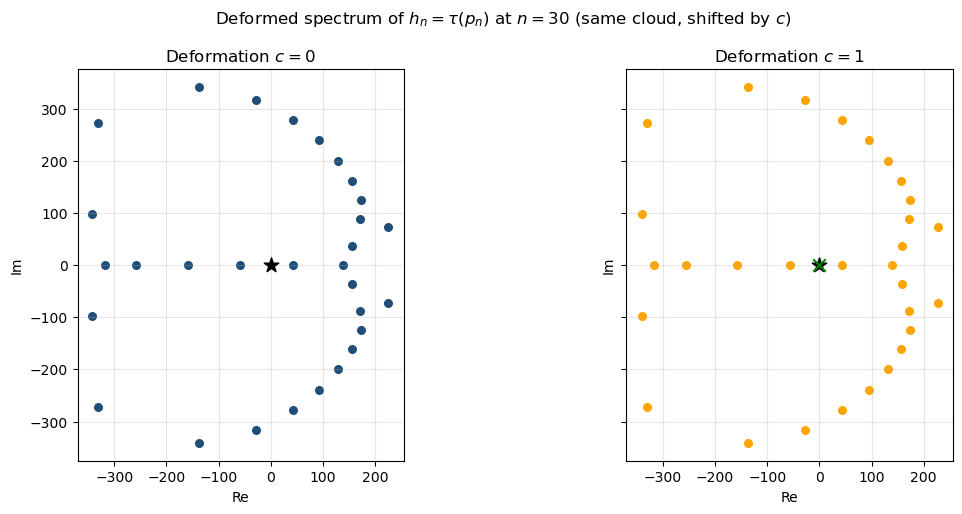

c=0:  min|z| = 42.467   max|z| = 429.081
c=1:  min|z| = 43.467   max|z| = 428.310


In [15]:
# =============================================================================
#  Deformed root clouds for h_n = tau(p_n), shown in two separate panels:
#    left  = deformation c = 0  (Phi_n)
#    right = deformation c = 1  (Phi_n shifted by 1)
#  Paste into a SageMath Jupyter notebook cell and run.
# =============================================================================
import matplotlib.pyplot as plt

# --- equation (D) and its inverse (your definitions) -------------------------
def h_sequence_from_j(j_list):
    h = [QQ(1)]                                   # h_0 = 1  (hard-wired seed)
    for n in range(1, len(j_list) + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s) / n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    j = []
    for n in range(1, len(h_list)):
        s = sum(j[r-1] * h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j

# --- data:  h_0 = 1,  h_n = tau(p_n) -----------------------------------------
N = 30                                            # the n used in the figure
D = delta_qexp(4000)
h_list = [QQ(1)] + [QQ(D[nth_prime(k)]) for k in range(1, N + 1)]
j_list = j_sequence_from_h(h_list)

# --- deformation = prepend c to the j-sequence (keeps h_0 = 1) ----------------
h0 = h_sequence_from_j([QQ(0)] + j_list)          # c = 0  ->  Phi_n
h1 = h_sequence_from_j([QQ(1)] + j_list)          # c = 1  ->  Phi_n( . - 1)

# --- characteristic polynomial (your Theorem 2.3), monic, and its roots -------
Rx.<x> = PolynomialRing(QQ)
def char_poly(hseq, n):
    return sum(binomial(n, r) * factorial(r) * hseq[r] * (-1)**r * x**(n - r)
               for r in range(n + 1))

CF = ComplexField(300)                            # high precision; raise with N
R0 = [complex(z) for z in char_poly(h0, N).roots(CF, multiplicities=False)]
R1 = [complex(z) for z in char_poly(h1, N).roots(CF, multiplicities=False)]

# --- the two deformations, shown in separate panels ---------------------------
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(12, 5.2), sharex=True, sharey=True)

ax0.scatter([z.real for z in R0], [z.imag for z in R0], s=30, color='#1f4e79')
ax0.scatter([0], [0], marker='*', color='black', s=120, zorder=5)    # origin (= -c)
ax0.set_title(r'Deformation $c=0$')

ax1.scatter([z.real for z in R1], [z.imag for z in R1], s=30, color='orange')
ax1.scatter([0], [0],  marker='*', color='black', s=120, zorder=5)   # origin
ax1.scatter([-1], [0], marker='x', color='green',  s=80, zorder=6)   # the point -c
ax1.set_title(r'Deformation $c=1$')

for ax in (ax0, ax1):
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
fig.suptitle(r'Deformed spectrum of $h_n=\tau(p_n)$ at $n=%d$ '
             r'(same cloud, shifted by $c$)' % N)
plt.tight_layout()
plt.savefig('tau_spectra_separate.png', dpi=140)
plt.show()

# sanity check (matches the figure): min/max modulus, and c=1 == c=0 shifted by 1
print("c=0:  min|z| = %.3f   max|z| = %.3f" % (min(abs(z) for z in R0),
                                               max(abs(z) for z in R0)))
print("c=1:  min|z| = %.3f   max|z| = %.3f" % (min(abs(z) for z in R1),
                                               max(abs(z) for z in R1)))


In [ ]:
import pickle

#with open('/Users/barrybrent/data2/run16jun26no4.txt', 'wb') as wfile:
 #   pickle.dump(chi_list, wfile)

with open('/Users/barrybrent/data2/run16jun26no4.txt', 'rb') as rfile:
    chi_list = pickle.load(rfile)


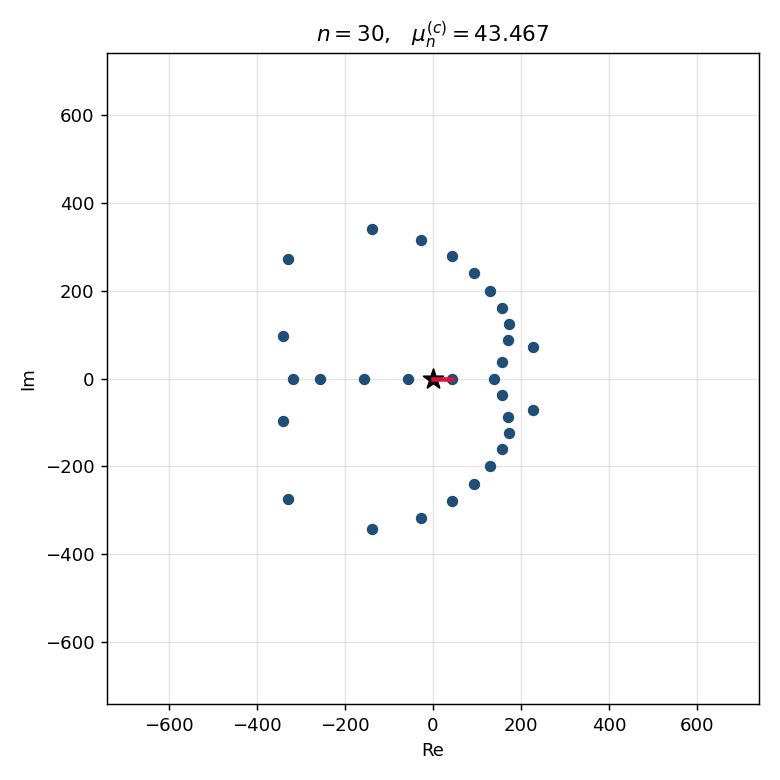

n = 30:  mu = 43.46701899591326   nearest zero = (43.46701899591326+0j)


In [4]:
# =============================================================================
#  Movie still-frame: the full deformed RING of zeros at a given n, with a
#  bright chord from the origin to the minimum-modulus zero drawn inside it.
#  h_n = tau(p_n), deform by c.  Paste into a SageMath Jupyter notebook.
# =============================================================================
import matplotlib.pyplot as plt
from IPython.display import Image as IPImage, display

# ---- equation (D) and its inverse (your definitions) ----
def h_sequence_from_j(j_list):
    h = [QQ(1)]
    for n in range(1, len(j_list) + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h.append((j_list[n-1] + s) / n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    j = []
    for n in range(1, len(h_list)):
        s = sum(j[r-1] * h_list[n-r] for r in range(1, n))
        j.append(n*h_list[n] - s)
    return j

# ---- one-time setup: compute the deformed h-sequence once ----
NMAX = 44                       # largest frame you intend to render
c    = QQ(1)                    # deformation parameter
prec = 300                      # ComplexField precision; raise ~1 bit per unit n
D = delta_qexp(4000)
H_full = [QQ(1)] + [QQ(D[nth_prime(k)]) for k in range(1, NMAX + 1)]
HC = h_sequence_from_j([c] + j_sequence_from_h(H_full))    # deformed sequence
CF = ComplexField(prec)
Rx.<x> = PolynomialRing(QQ)

def deformed_roots(n):
    p = sum(binomial(n, r) * factorial(r) * HC[r] * (-1)**r * x**(n - r)
            for r in range(n + 1))
    return [complex(z) for z in p.roots(CF, multiplicities=False)]

# ---- the still-frame: full ring, with the chord drawn inside it ----
def make_frame(n, lim, fname=None, show=True):
    roots = deformed_roots(n)
    zmin  = min(roots, key=abs)            # the minimum-modulus zero
    mu    = abs(zmin)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter([z.real for z in roots], [z.imag for z in roots],
               s=28, color='#1f4e79', zorder=3)               # the ring of zeros
    ax.scatter([0], [0], marker='*', color='black', s=130, zorder=5)   # the origin

    # >>> THE CHORD: bright segment from the origin to the nearest zero <<<
    ax.plot([0, zmin.real], [0, zmin.imag], color='crimson', lw=2.5, zorder=6)
    # <<< end chord >>>

    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_aspect('equal'); ax.grid(alpha=0.3)
    ax.set_xlabel('Re'); ax.set_ylabel('Im')
    ax.set_title(r'$n=%d$,   $\mu_n^{(c)}=%.3f$' % (n, mu))

    if fname is None:
        fname = 'frame_n%03d.png' % n
    plt.tight_layout()
    plt.savefig(fname, dpi=130)
    plt.close(fig)
    if show:
        display(IPImage(filename=fname))   # render the saved PNG inline
    return mu, zmin

# ---- ONE fixed window holding the WHOLE ring, for every frame ----
L_full = 1.08 * max(abs(z) for z in deformed_roots(NMAX))   # whole ring in view
LIM_full = (-L_full, L_full)

# demo: full ring with the crimson chord inside it
mu, zmin = make_frame(30, LIM_full)
print("n = 30:  mu =", mu, "  nearest zero =", zmin)
